# Just-image Transformer (JiT) with Flow Divergence Sampler (FDS)

This notebook samples from pre-trained JiT models. JiT is a class-conditional image generation model trained on ImageNet that operates directly in pixel space using a flow-matching objective. FDS (Flow Divergence Sampler) is a training-free inference-time enhancement that selects lower-divergence trajectories at each ODE timestep to improve sample quality.

# 1. Setup

We recommend using GPUs. Run this cell to import dependencies and set up the environment.

In [1]:
import os
import sys
import copy
import types

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from torchvision.utils import make_grid

# Add src to path
sys.path.insert(0, os.path.join(os.path.abspath('.'), 'src'))

from denoiser import DenoiserCustom

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("GPU not found. Using CPU instead.")
else:
    print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")

Using device: cuda (NVIDIA GeForce RTX 3090)


# 2. Load Pre-trained JiT Model

Choose a checkpoint from `checkpoints/`. Available models:
- `JiT-B/16` — Base model, patch size 16
- `JiT-L/16` — Large model, patch size 32

In [7]:
# Model selection
model_name = "JiT-B/16"  # @param ["JiT-B/16", "JiT-B/32", "JiT-H/16"]

checkpoint_map = {
    "JiT-B/16": "checkpoints/jit-b-16/checkpoint-last.pth",
    "JiT-B/32": "checkpoints/jit-b-32/checkpoint-last.pth",
    "JiT-H/16": "checkpoints/jit-h-16/checkpoint-last.pth",
}
checkpoint_path = checkpoint_map[model_name]

# Build args namespace (mirrors main_jit.py defaults)
args = types.SimpleNamespace(
    model=model_name,
    img_size=256,
    attn_dropout=0.0,
    proj_dropout=0.0,
    class_num=1000,
    label_drop_prob=0.1,
    P_mean=-0.8,
    P_std=0.8,
    noise_scale=1.0,
    t_eps=5e-2,
    ema_decay1=0.9999,
    ema_decay2=0.9996,
    sampling_method="heun",
    num_sampling_steps=50,
    cfg=1.5,
    interval_min=0.0,
    interval_max=1.0,
    iter=1,
    perturb_scale=1e-2,
    perturb_schedule="cosine",
    iter_schedule="linear",
    stop_t=0.5,
    seed_delta=42,
    seed_eps=1234,
    num_delta=1,
    sync_over_time=False,
)

# Instantiate model
model = DenoiserCustom(args)
model.to(device)

# Load checkpoint
print(f"Loading checkpoint: {checkpoint_path}")
checkpoint = torch.load(checkpoint_path, map_location="cpu")
model.load_state_dict(checkpoint["model"])

ema_state_dict1 = checkpoint["model_ema1"]
ema_state_dict2 = checkpoint["model_ema2"]
model.ema_params1 = [ema_state_dict1[name].to(device) for name, _ in model.named_parameters()]
model.ema_params2 = [ema_state_dict2[name].to(device) for name, _ in model.named_parameters()]
del checkpoint

# Switch to EMA weights for generation (mirrors engine_jit.py evaluate())
ema_state = copy.deepcopy(model.state_dict())
for i, (name, _) in enumerate(model.named_parameters()):
    ema_state[name] = model.ema_params1[i]
model.load_state_dict(ema_state)
model.eval()
print("Model loaded and switched to EMA weights.")

n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params / 1e6:.1f}M")

Loading checkpoint: checkpoints/jit-b-16/checkpoint-last.pth
Model loaded and switched to EMA weights.
Parameters: 131.3M


# 2. Comparison: Vanilla vs FDS

Compare vanilla Heun and Heun+FDS using the same seed and class labels.

Running vanilla Heun...


100%|██████████| 49/49 [00:01<00:00, 26.05it/s]


Running Heun + FDS...


100%|██████████| 49/49 [00:02<00:00, 16.85it/s]


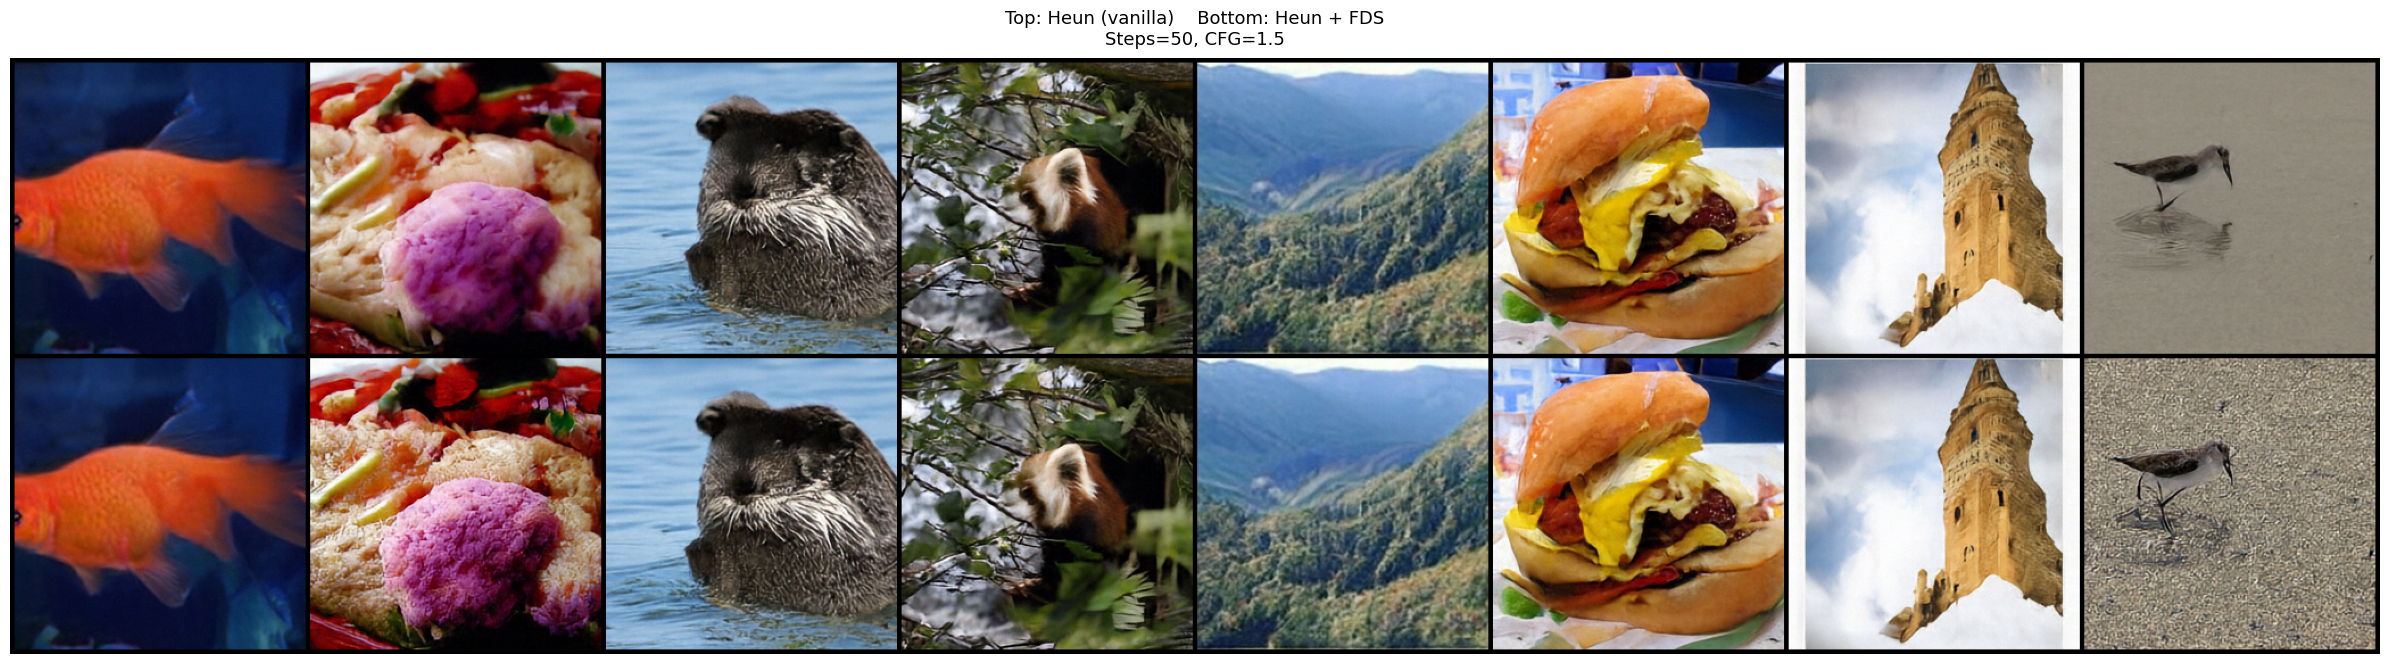

Saved to results/comparison.png


In [ ]:
seed = 0                                               # @param {type:"number"}
num_sampling_steps = 50                                # @param {type:"slider", min:10, max:250, step:10}
cfg_scale = 1.5                                        # @param {type:"slider", min:1.0, max:8.0, step:0.1}
class_labels = (1, 938, 360, 387, 979, 933, 483, 140)  # @param {type:"raw"}

os.makedirs("results", exist_ok=True)

def run_sampling(method, seed, class_labels, num_steps, cfg):
    torch.manual_seed(seed)
    args.sampling_method = method
    args.num_sampling_steps = num_steps
    args.cfg = cfg
    model.method = method
    model.steps = num_steps
    model.cfg_scale = cfg
    labels = torch.tensor(class_labels, device=device)
    grad_needed = "ours" in method
    torch.set_grad_enabled(grad_needed)
    with torch.amp.autocast("cuda", dtype=torch.bfloat16):
        out = model.generate(labels, args)
    torch.set_grad_enabled(False)
    out = (out.float() + 1.0) / 2.0
    return out.clamp(0, 1).cpu()

print("Running vanilla Heun...")
vanilla_samples = run_sampling("heun", seed, class_labels, num_sampling_steps, cfg_scale)

print("Running Heun + FDS...")
args.iter = 1
args.perturb_scale = 1e-2
args.stop_t = 0.5
fds_samples = run_sampling("heun_ours", seed, class_labels, num_sampling_steps, cfg_scale)

# Two-row grid: vanilla on top, FDS on bottom
n = len(class_labels)
all_samples = torch.cat([vanilla_samples, fds_samples], dim=0)
grid = make_grid(all_samples, nrow=n, padding=4)
grid_np = (grid.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

fig, ax = plt.subplots(figsize=(n * 3, 7))
ax.imshow(grid_np)
ax.axis("off")
ax.set_title(
    f"Top: Heun (vanilla)    Bottom: Heun + FDS\n"
    f"Steps={num_sampling_steps}, CFG={cfg_scale}",
    fontsize=13, pad=10
)
plt.tight_layout()
plt.savefig("results/comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to results/comparison.png") 